In [64]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from vinesforest import VinesForest
from vinesforest.grid_size import grid_size_1d, grid_size_1d_many, grid_size_2d
from vinesforest.uniform import Uniform

import pyvinecopulib as pv

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
datasets = {
  "power": "power/data.npy",
  "gas": "gas/ethylene_CO.csv",
  "hepmass": "hepmass",
  "miniboone": "miniboone/data.npy",
}
dataset = "hepmass"

# (1659917, 6)
# (852174, 8)
# (315123, 21)
# (29556, 43)

if dataset not in datasets:
  raise ValueError(f"Dataset {dataset} not in {datasets}")

# Dynamically import module
module = importlib.import_module(f"uci.{dataset}")

# Dynamically get class
cls = getattr(module, dataset.upper())

# Instantiate
data = cls(f"uci/data/{datasets[dataset]}")

/home/tvatter/Dropbox/github/pyvinecopulib/examples/forests/uci/hepmass.py:30: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  data_train = pd.read_csv(


In [108]:
x_trn = data.trn.x
x_val = data.val.x
x_tst = data.tst.x

In [109]:
print(pd.DataFrame(x_trn).describe())
print(pd.DataFrame(x_tst).describe())

              0          1           2          3          4          5          6          7          8          9          10         11         12         13         14         15          16         17         18         19         20
count  3.151e+05  3.151e+05  315123.000  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  3.151e+05  315123.000  3.151e+05  3.151e+05  3.151e+05  3.151e+05
mean   5.901e-04 -1.542e-04      -0.001  5.313e-04 -1.791e-04  3.159e-04  3.933e-04  1.904e-05 -4.342e-04  2.976e-04 -1.938e-04 -5.324e-04 -2.659e-04  2.582e-04  9.287e-05 -2.582e-04       0.001  6.582e-05  3.235e-04 -2.465e-04  7.193e-05
std    1.000e+00  9.997e-01       1.000  9.989e-01  1.000e+00  1.000e+00  9.995e-01  9.999e-01  1.001e+00  1.001e+00  1.000e+00  1.000e+00  1.000e+00  9.996e-01  9.996e-01  9.996e-01       1.000  1.000e+00  1.000e+00  1.000e+00  9.999e-01
min   -2.265e+00 -2.532e+00      -1.734 -8.0

In [123]:
import math

import numpy as np


def plot_grid(x_trn, x_val, margins):
  d = x_trn.shape[1]

  # grid layout ~ square
  ncols = math.ceil(math.sqrt(d))
  nrows = math.ceil(d / ncols)

  fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False
  )
  axes = axes.ravel()

  for i in range(d):
    ax = axes[i]
    ax.set_title(f"Variable {i}")

    # histograms
    ax.hist(x_trn[:, i], bins=100, density=True, alpha=0.5, label="Training")
    ax.hist(x_val[:, i], bins=100, density=True, alpha=0.5, label="Validation")

    # KDE PDF
    if isinstance(margins[i], pv.Kde1d):
      xmin = margins[i].grid_points.min()
      xmax = margins[i].grid_points.max()
    else:
      xmin = margins[i].xmin
      xmax = margins[i].xmax
    x = np.linspace(xmin, xmax, 1000)
    ax.plot(x, margins[i].pdf(x), label="KDE PDF")

    ax.set_xlabel(f"Variable {i}")
    ax.set_ylabel("Density")

  # turn off extra axes
  for j in range(d, len(axes)):
    axes[j].axis("off")

  # single, global legend
  handles, labels = axes[0].get_legend_handles_labels()
  fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

  plt.tight_layout()
  plt.subplots_adjust(top=0.92)  # leave space for legend
  plt.show()
  return None  # ensures no echoed output

In [110]:
lengths = [
  float(x_trn[:, i].max() - x_trn[:, i].min()) for i in range(x_trn.shape[1])
]

grid_sizes_1d = [
  grid_size_1d(x_trn.shape[0], c=0.7, length=lengths[i])
  for i in range(x_trn.shape[1])
]
grid_sizes_1d_cap = grid_size_1d_many(x_trn.shape[0], lengths=lengths)
print("Grid sizes:", grid_sizes_1d)
print("Grid sizes (capped):", grid_sizes_1d_cap)

Grid sizes: [1278, 1145, 784, 2444, 783, 2234, 1379, 783, 1964, 1239, 784, 1706, 1141, 783, 1427, 1041, 784, 2025, 2453, 3592, 1495]
Grid sizes (capped): [1138, 1019, 698, 2048, 697, 1989, 1228, 697, 1748, 1103, 698, 1519, 1016, 697, 1271, 927, 698, 1803, 2048, 2048, 1331]


In [ ]:
d = x_trn.shape[1]
margins_controls = {
  i: {
    "kde": {
      "type": "continuous",
      "degree": 0,
      # "grid_size": grid_sizes_1d_cap[i],
    }
  }
  for i in range(d)
}
uniform_variables = [2, 4, 7, 10, 13, 16]
for i in uniform_variables:
  del margins_controls[i]["kde"]
  margins_controls[i]["uniform"] = {
    "xmin": min(x_trn[:, i].min(), x_val[:, i].min(), x_tst[:, i].min()),
    "xmax": max(x_trn[:, i].max(), x_val[:, i].max(), x_tst[:, i].max()),
  }
# # left_bounded = [1, 3, 4, 5]
# # for i in left_bounded:
# #   margins_controls[i]["kde"]["xmin"] = min(
# #     x_trn[:, i].min(), x_val[:, i].min(), x_tst[:, i].min()
# #   )


margins = [
  pv.Kde1d(**margins_controls[i]["kde"])
  if "kde" in margins_controls[i]
  else Uniform(**margins_controls[i]["uniform"])
  for i in range(d)
]
for i in range(d):
  margins[i].fit(x_trn[:, i])

margins_loglik = np.column_stack(
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]
)
margins_loglik.mean(axis=0)

plot_grid(x_trn, x_val, margins)

/tmp/ipykernel_1819159/533295723.py:36: RuntimeWarning: divide by zero encountered in log
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]


array([-1.36577787, -1.40658   , -1.24245632, -1.35414132, -1.24167085,
       -1.4030384 , -1.41526407, -1.2416029 , -1.41652213, -1.41284051,
       -1.2425921 , -1.41774962, -1.40714361, -1.24193501, -1.38839776,
       -1.39221563, -1.24275243, -1.35368798, -1.11113272,        -inf,
       -1.20362709])

In [71]:
u_trn = np.column_stack([margins[i].cdf(x_trn[:, i]) for i in range(d)])
u_val = np.column_stack([margins[i].cdf(x_val[:, i]) for i in range(d)])
u_tst = np.column_stack([margins[i].cdf(x_tst[:, i]) for i in range(d)])

In [72]:
# i = 0
# multiplier = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
# val_loglik = []
# for m in multiplier:
#   margins = [
#     pv.Kde1d(**margins_controls[i]["kde"], degree=0, multiplier=m)
#     for i in range(d)
#   ]
#   for i in range(d):
#     margins[i].fit(x_trn[:, i])

#   margins_loglik = np.column_stack(
#     [np.log(margins[i].pdf(x_val[:, i])) for i in range(d)]
#   )
#   val_loglik.append(margins_loglik.mean(axis=0))

# val_loglik = np.array(val_loglik)

# plt.figure(figsize=(10, 6))
# plt.plot(multiplier, val_loglik[:, 0], label="x1")
# plt.plot(multiplier, val_loglik[:, 1], label="x2")
# plt.plot(multiplier, val_loglik[:, 2], label="x3")
# plt.plot(multiplier, val_loglik[:, 3], label="x4")
# plt.plot(multiplier, val_loglik[:, 4], label="x5")
# plt.plot(multiplier, val_loglik[:, 5], label="x6")
# plt.xscale("log")
# plt.xlabel("Multiplier")
# plt.ylabel("Log-likelihood")
# plt.title("Validation log-likelihood for different multipliers")
# plt.legend()
# plt.grid()
# plt.show()

In [104]:
margins[5]

<pyvinecopulib.Kde1d> Kde1d(xmin=-2.04916, xmax=nan, type='continuous', bandwidth=0.0118071, multiplier=1, degree=0)

In [103]:
x_trn[x_trn[:, 5] < -2.0, 5]

array([-2.038506 , -2.049156 , -2.0128312, -2.0074775, -2.0042539,
       -2.0245748, -2.034246 , -2.0256686, -2.0021238, -2.0160549,
       -2.0310223, -2.018185 , -2.0128312, -2.00103  , -2.0053475,
       -2.0021238, -2.0117376, -2.0160549, -2.00103  , -2.018185 ,
       -2.0277987, -2.0149612, -2.0427659], dtype=float32)

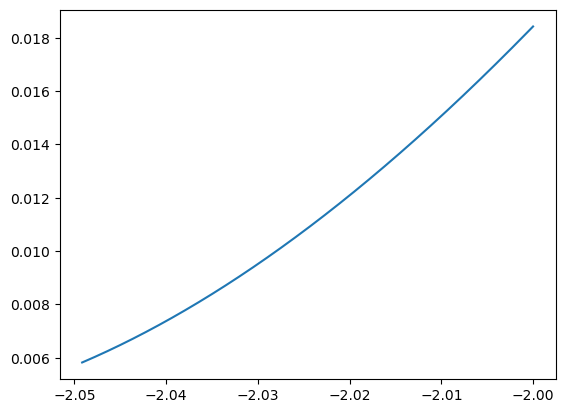

In [106]:
x = np.linspace(x_trn[:, 5].min(), -2.0, 1000)
plt.plot(x, margins[5].pdf(x), label="KDE PDF")
plt.show()

In [76]:
# spot the -Inf indices
margins_loglik = np.column_stack(
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]
)
problems = np.where(margins_loglik == -np.inf)
print(x_tst[problems[0], problems[1]], problems[1])

[-2.0395422] [5]


/tmp/ipykernel_1819159/3301065887.py:3: RuntimeWarning: divide by zero encountered in log
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]


In [14]:
sample_size_fit = 200000
sample_size_select = 2000
nonparametric_grid_size_fit = grid_size_2d(sample_size_fit, h=None, c=0.7)
nonparametric_grid_size_select = grid_size_2d(sample_size_select, h=None, c=0.7)
num_threads = 60
controls_fit = pv.FitControlsVinecop(
  family_set=[pv.tll],
  num_threads=num_threads,
  nonparametric_grid_size=nonparametric_grid_size_fit,
)
controls_select = pv.FitControlsVinecop(
  family_set=[pv.tll],
  num_threads=num_threads,
  nonparametric_grid_size=nonparametric_grid_size_select,
)

In [16]:
u_trn_sub = u_trn[
  np.random.choice(u_trn.shape[0], sample_size_fit, replace=False), :
]
cop = pv.Vinecop.from_data(u_trn_sub, controls=controls_fit)

In [50]:
margins[3]

<pyvinecopulib.Kde1d> Kde1d(xmin=nan, xmax=nan, type='continuous', bandwidth=0.00679554, multiplier=1, degree=0)

[-1.8433168 -1.8641864 -2.0395422 67.171715 ] [4 4 5 3]


In [ ]:
u_tst = np.column_stack([margins[i].cdf(x_tst[:, i]) for i in range(d)])

cop_loglik = np.log(cop.pdf(u_tst)).mean()
print(
  cop_loglik,
  margins_loglik.mean(axis=0).sum(),
  margins_loglik.mean(axis=0).sum() + cop_loglik,
)

/tmp/ipykernel_1819159/2377564154.py:3: RuntimeWarning: divide by zero encountered in log
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]


10.427072769366633 -inf -inf


In [26]:
# Create an instance of VinesForest
forest = VinesForest(controls=controls_select)

# Subsampled data for training
u_trn_sub = u_trn[
  np.random.choice(u_trn.shape[0], sample_size_select, replace=False), :
]
u_val_sub = u_val[
  np.random.choice(u_val.shape[0], sample_size_select, replace=False), :
]
forest.fit(u_trn_sub, u_val_sub)

In [28]:
best_vine = forest.logliks_forest.mean(axis=1).argmax()
u_trn_sub = u_trn[
  np.random.choice(u_trn.shape[0], sample_size_fit, replace=False), :
]
cop2 = forest.vines[best_vine]
cop2.from_data(
  u_trn_sub,
  structure=cop2.structure,
  controls=controls_fit,
)
np.log(cop2.pdf(u_tst)).mean()

<pyvinecopulib.Vinecop> Vinecop model with 6 variables
tree edge conditioned variables conditioning variables var_types family rotation   parameters    df   tau 
   1    1                  6, 2                             c, c    TLL          [30x30 grid] 411.9 -0.12 
   1    2                  1, 5                             c, c    TLL          [30x30 grid] 413.8  0.39 
   1    3                  2, 5                             c, c    TLL          [30x30 grid] 416.2 -0.12 
   1    4                  3, 5                             c, c    TLL          [30x30 grid] 502.9  0.04 
   1    5                  4, 5                             c, c    TLL          [30x30 grid] 477.7  0.02 
   2    1                  6, 5                      2      c, c    TLL          [30x30 grid] 469.1  0.04 
   2    2                  1, 4                      5      c, c    TLL          [30x30 grid] 366.3  0.13 
   2    3                  2, 4                      5      c, c    TLL          [30x30 g

np.float64(0.7147309262029685)

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Log-Likelihood of Test Data')

(array([2.00000e+00, 2.00000e+00, 3.00000e+00, 1.00000e+01, 1.01000e+02,
        4.25000e+02, 1.26200e+03, 6.46200e+03, 3.01600e+04, 1.66501e+05]),
 array([-13.40570643, -12.13283935, -10.85997226,  -9.58710518,
         -8.3142381 ,  -7.04137102,  -5.76850394,  -4.49563686,
         -3.22276978,  -1.9499027 ,  -0.67703562]),
 <BarContainer object of 10 artists>)

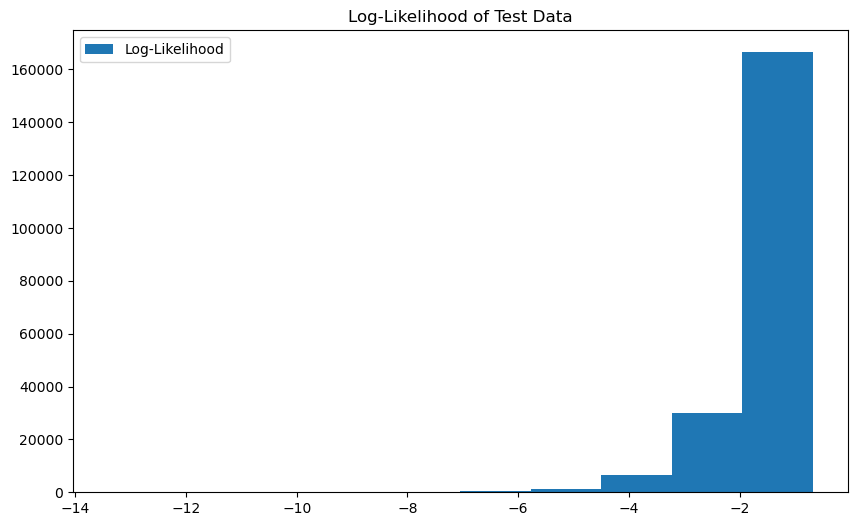

In [39]:
plt.figure(figsize=(10, 6))
plt.title("Log-Likelihood of Test Data")
plt.hist(margins_loglik[:, 1], label="Log-Likelihood")
plt.legend()
plt.show()

In [ ]:
u_tst = np.column_stack([margins[i].cdf(x_tst[:, i]) for i in range(d)])
margins_loglik = np.column_stack(
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]
)
cop_loglik = np.log(cop.pdf(u_tst)).mean()
print(
  cop_loglik,
  margins_loglik.mean(axis=0).sum(),
  margins_loglik.mean(axis=0).sum() + cop_loglik,
)

cop2_loglik = np.log(cop2.pdf(u_tst)).mean()
print(
  cop2_loglik,
  margins_loglik.mean(axis=0).sum(),
  margins_loglik.mean(axis=0).sum() + cop2_loglik,
)

0.935617196034843 -0.8773928531519191 0.058224342882923885
0.9865773291374371 -0.8773928531519191 0.10918447598551806


<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 0')

(array([1.03314943, 0.97611662, 1.08276798, 0.98923417, 1.02031705,
        0.98752318, 0.96128809, 0.98780835, 0.93790463, 1.04626698,
        0.97497596, 1.01318795, 1.01290278, 0.96727653, 0.97041334,
        0.99037482, 1.00064073, 1.0183209 , 0.97725728, 0.98010892,
        1.01632475, 0.98296056, 1.01147696, 0.99237097, 1.00862532,
        1.02459451, 1.02345385, 1.02174287, 0.9778276 , 1.01375828]),
 array([6.78923083e-06, 3.33390433e-02, 6.66712974e-02, 1.00003551e-01,
        1.33335806e-01, 1.66668060e-01, 2.00000314e-01, 2.33332568e-01,
        2.66664822e-01, 2.99997076e-01, 3.33329330e-01, 3.66661584e-01,
        3.99993838e-01, 4.33326092e-01, 4.66658346e-01, 4.99990600e-01,
        5.33322854e-01, 5.66655108e-01, 5.99987362e-01, 6.33319617e-01,
        6.66651871e-01, 6.99984125e-01, 7.33316379e-01, 7.66648633e-01,
        7.99980887e-01, 8.33313141e-01, 8.66645395e-01, 8.99977649e-01,
        9.33309903e-01, 9.66642157e-01, 9.99974411e-01]),
 <BarContainer object of 30 

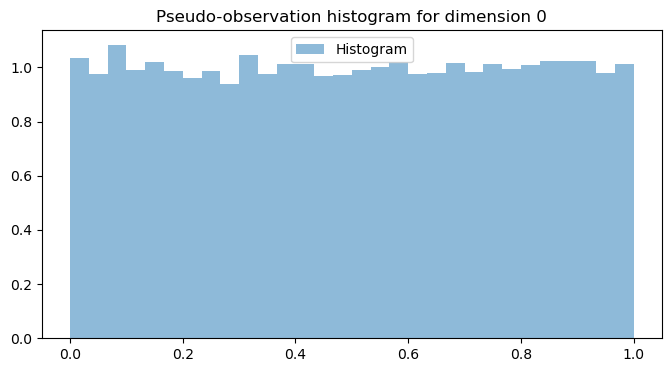

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 1')

(array([0.96671675, 1.00863633, 1.04998557, 0.98211578, 1.02118368,
        1.01804684, 1.00293298, 0.97013876, 1.07365444, 1.04000472,
        0.9741311 , 0.99808514, 0.96985359, 1.03943438, 0.95730623,
        0.98154544, 1.01776168, 1.05426308, 0.96357991, 0.98154544,
        1.04342672, 0.95103256, 1.00321815, 1.02375019, 0.95074739,
        0.95958757, 0.98240095, 1.03886405, 0.99352247, 0.98382678]),
 array([4.05887153e-05, 3.33724791e-02, 6.67043696e-02, 1.00036260e-01,
        1.33368150e-01, 1.66700041e-01, 2.00031931e-01, 2.33363822e-01,
        2.66695712e-01, 3.00027603e-01, 3.33359493e-01, 3.66691383e-01,
        4.00023274e-01, 4.33355164e-01, 4.66687055e-01, 5.00018945e-01,
        5.33350836e-01, 5.66682726e-01, 6.00014616e-01, 6.33346507e-01,
        6.66678397e-01, 7.00010288e-01, 7.33342178e-01, 7.66674069e-01,
        8.00005959e-01, 8.33337849e-01, 8.66669740e-01, 9.00001630e-01,
        9.33333521e-01, 9.66665411e-01, 9.99997301e-01]),
 <BarContainer object of 30 

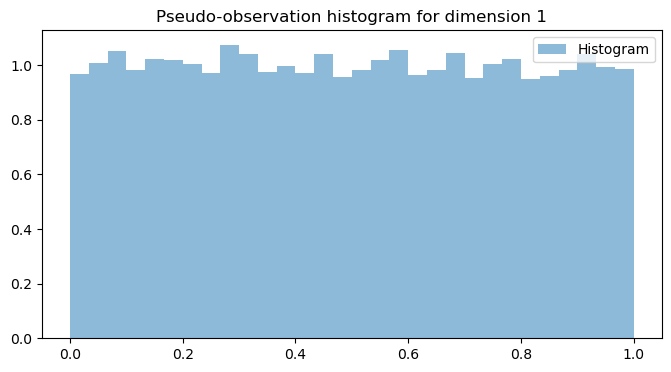

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 2')

(array([1.03198424, 1.01259355, 1.00746071, 1.00860134, 1.00175757,
        0.97923014, 1.00204273, 0.9755231 , 1.01259355, 0.99320285,
        0.99947631, 0.98265203, 0.99348801, 0.99035128, 1.03939833,
        1.00574977, 1.02086311, 0.99491379, 0.95841366, 0.96269102,
        1.02000764, 0.98293719, 0.97723404, 0.99690989, 1.0128787 ,
        1.00603493, 1.01145292, 0.9755231 , 1.03597644, 1.00831619]),
 array([6.82872732e-06, 3.33398753e-02, 6.66729218e-02, 1.00005968e-01,
        1.33339015e-01, 1.66672061e-01, 2.00005108e-01, 2.33338154e-01,
        2.66671201e-01, 3.00004248e-01, 3.33337294e-01, 3.66670341e-01,
        4.00003387e-01, 4.33336434e-01, 4.66669480e-01, 5.00002527e-01,
        5.33335573e-01, 5.66668620e-01, 6.00001666e-01, 6.33334713e-01,
        6.66667759e-01, 7.00000806e-01, 7.33333852e-01, 7.66666899e-01,
        7.99999946e-01, 8.33332992e-01, 8.66666039e-01, 8.99999085e-01,
        9.33332132e-01, 9.66665178e-01, 9.99998225e-01]),
 <BarContainer object of 30 

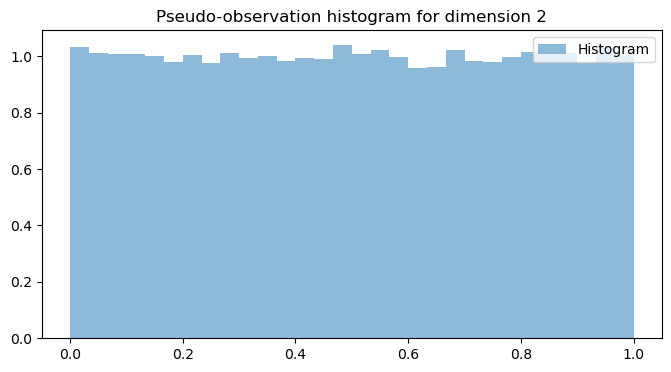

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 3')

(array([1.18005878, 0.90259939, 0.98509503, 0.96397158, 1.03362188,
        0.95854799, 1.02620012, 1.05931256, 1.02762738, 1.07957966,
        0.99394404, 0.86035248, 0.98566593, 1.20175314, 0.91401747,
        0.93571182, 0.84750714, 0.96625519, 1.20660582, 1.00621848,
        0.88718498, 1.00536212, 0.98366777, 1.01535295, 0.9459881 ,
        1.07986511, 1.08785777, 0.97938599, 1.00165125, 0.91030659]),
 array([0.00103804, 0.03433666, 0.06763529, 0.10093392, 0.13423254,
        0.16753117, 0.2008298 , 0.23412842, 0.26742705, 0.30072568,
        0.3340243 , 0.36732293, 0.40062156, 0.43392018, 0.46721881,
        0.50051744, 0.53381606, 0.56711469, 0.60041332, 0.63371194,
        0.66701057, 0.7003092 , 0.73360782, 0.76690645, 0.80020508,
        0.8335037 , 0.86680233, 0.90010096, 0.93339958, 0.96669821,
        0.99999684]),
 <BarContainer object of 30 artists>)

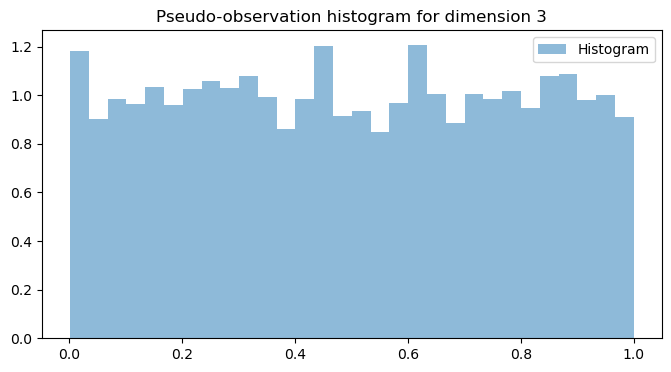

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 4')

(array([1.03197751, 1.0026065 , 1.01943068, 0.98350109, 1.02285254,
        0.99262606, 0.99062998, 0.96667692, 1.00346197, 0.95812226,
        1.01857521, 1.05022746, 0.97123941, 0.97608705, 1.03368845,
        1.00602837, 0.94215355, 1.01315726, 1.00602837, 0.96582145,
        0.99804402, 1.03083689, 0.99490731, 1.00602837, 0.97751283,
        1.03939156, 0.96582145, 1.01087601, 1.02000099, 1.00175104]),
 array([0.        , 0.03333326, 0.06666653, 0.09999979, 0.13333306,
        0.16666632, 0.19999958, 0.23333285, 0.26666611, 0.29999937,
        0.33333264, 0.3666659 , 0.39999917, 0.43333243, 0.46666569,
        0.49999896, 0.53333222, 0.56666549, 0.59999875, 0.63333201,
        0.66666528, 0.69999854, 0.7333318 , 0.76666507, 0.79999833,
        0.8333316 , 0.86666486, 0.89999812, 0.93333139, 0.96666465,
        0.99999791]),
 <BarContainer object of 30 artists>)

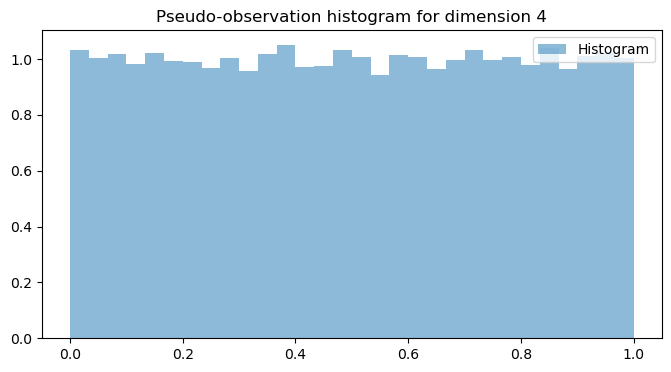

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 5')

(array([1.03140907, 0.99490911, 1.00517473, 1.01601065, 1.00945207,
        0.99662005, 0.97779975, 1.00232317, 0.97551851, 0.99547942,
        1.01258878, 1.01087784, 0.99405364, 0.97865522, 1.00745597,
        1.01686612, 1.00802629, 0.98093647, 0.99861614, 1.01886221,
        0.96610836, 0.98264741, 0.97380757, 0.99604974, 1.06135045,
        0.9917724 , 0.94500682, 1.01344425, 1.02941298, 1.00888175]),
 array([1.86926988e-06, 3.33350727e-02, 6.66682761e-02, 1.00001479e-01,
        1.33334683e-01, 1.66667886e-01, 2.00001090e-01, 2.33334293e-01,
        2.66667496e-01, 3.00000700e-01, 3.33333903e-01, 3.66667107e-01,
        4.00000310e-01, 4.33333514e-01, 4.66666717e-01, 4.99999920e-01,
        5.33333124e-01, 5.66666327e-01, 5.99999531e-01, 6.33332734e-01,
        6.66665937e-01, 6.99999141e-01, 7.33332344e-01, 7.66665548e-01,
        7.99998751e-01, 8.33331954e-01, 8.66665158e-01, 8.99998361e-01,
        9.33331565e-01, 9.66664768e-01, 9.99997971e-01]),
 <BarContainer object of 30 

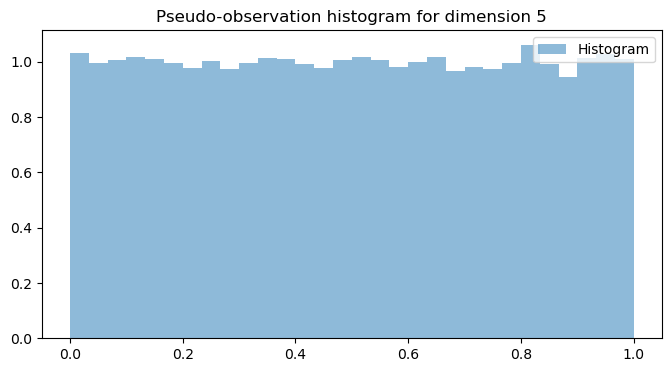

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 6')

(array([1.01294899, 1.03348174, 1.00667509, 1.01380452, 1.00125673,
        1.0015419 , 0.9741649 , 1.01637111, 0.99384212, 0.99270141,
        1.00496403, 0.97273902, 1.00924168, 1.00097155, 0.96389853,
        1.00696027, 1.01950806, 1.02834855, 0.97074278, 0.98443128,
        1.01009722, 1.00553438, 1.04146669, 1.02007841, 0.98015362,
        0.97188349, 1.00895651, 1.00696027, 0.97986844, 0.96874654]),
 array([2.85282148e-05, 3.33592620e-02, 6.66899957e-02, 1.00020729e-01,
        1.33351463e-01, 1.66682197e-01, 2.00012931e-01, 2.33343664e-01,
        2.66674398e-01, 3.00005132e-01, 3.33335866e-01, 3.66666599e-01,
        3.99997333e-01, 4.33328067e-01, 4.66658801e-01, 4.99989534e-01,
        5.33320268e-01, 5.66651002e-01, 5.99981735e-01, 6.33312469e-01,
        6.66643203e-01, 6.99973937e-01, 7.33304670e-01, 7.66635404e-01,
        7.99966138e-01, 8.33296872e-01, 8.66627605e-01, 8.99958339e-01,
        9.33289073e-01, 9.66619807e-01, 9.99950540e-01]),
 <BarContainer object of 30 

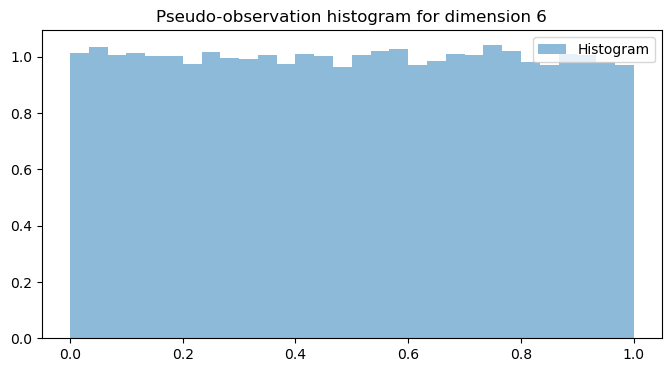

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 7')

(array([0.99954   , 1.05600475, 0.99212544, 1.01408395, 0.99126992,
        0.99668825, 1.00467316, 1.01208772, 0.99811413, 0.96303754,
        1.0123729 , 1.00524351, 0.97045211, 0.95048982, 1.06142308,
        0.96674483, 1.00324728, 0.9821443 , 1.03176483, 1.0123729 ,
        1.02007264, 0.92739061, 1.05315299, 0.9810036 , 1.03119448,
        1.00239176, 1.01522465, 1.00381764, 0.98357018, 0.96047097]),
 array([1.72523693e-05, 3.33481748e-02, 6.66790973e-02, 1.00010020e-01,
        1.33340942e-01, 1.66671865e-01, 2.00002787e-01, 2.33333710e-01,
        2.66664632e-01, 2.99995555e-01, 3.33326477e-01, 3.66657399e-01,
        3.99988322e-01, 4.33319244e-01, 4.66650167e-01, 4.99981089e-01,
        5.33312012e-01, 5.66642934e-01, 5.99973857e-01, 6.33304779e-01,
        6.66635702e-01, 6.99966624e-01, 7.33297547e-01, 7.66628469e-01,
        7.99959392e-01, 8.33290314e-01, 8.66621236e-01, 8.99952159e-01,
        9.33283081e-01, 9.66614004e-01, 9.99944926e-01]),
 <BarContainer object of 30 

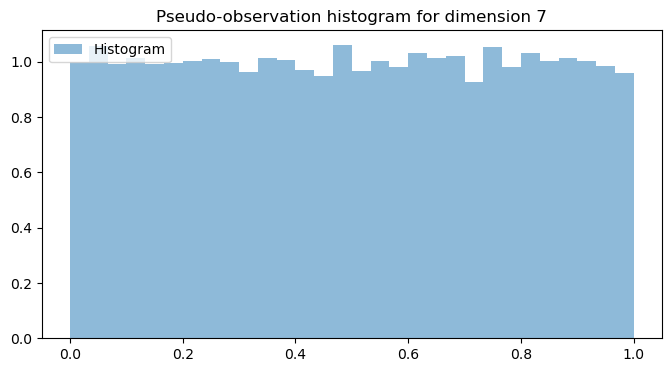

In [30]:
for i, model in enumerate(margins):
  plt.figure(figsize=(8, 4))
  plt.title(f"Pseudo-observation histogram for dimension {i}")
  plt.hist(u_tst[:, i], bins=30, density=True, alpha=0.5, label="Histogram")
  plt.legend()
  plt.show()